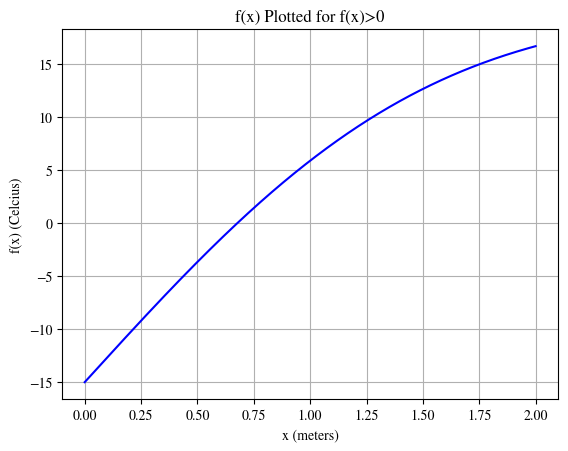

In [28]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib
import math
from scipy import special
%matplotlib inline
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

# 2


def f(x):
    Ti = 20
    Ts = -15
    alpha = 0.138e-6
    t = 60*86400
    return (Ti-Ts)*special.erf(x / (2*np.sqrt(alpha*t))) + Ts

x = np.linspace(0, 2, 1000)

plt.plot(x, f(x), color = "blue")
plt.title("f(x) Plotted for f(x)>0")
plt.xlabel('x (meters)')
plt.ylabel('f(x) (Celcius)')
plt.grid(True)
plt.savefig("Hw 3 Q2.pdf")
plt.show()

In [34]:
def bisection(f,a,b,tol):
    
#    Inputs:
#     f,a,b       - function and endpoints of initial interval
#      tol  - bisection stops when interval length < tol

#    Returns:
#      astar - approximation of root
#      ier   - error message
#            - ier = 1 => Failed
#            - ier = 0 == success

#     first verify there is a root we can find in the interval 

    fa = f(a)
    fb = f(b);
    if (fa*fb>0):
       ier = 1
       astar = a
       return [astar, ier]

#   verify end points are not a root 
    if (fa == 0):
      astar = a
      ier =0
      return [astar, ier]

    if (fb ==0):
      astar = b
      ier = 0
      return [astar, ier]

    count = 0
    d = 0.5*(a+b)
    while (abs(d-a)> tol):
      fd = f(d)
      if (fd ==0):
        astar = d
        ier = 0
        return [astar, ier]
      if (fa*fd<0):
         b = d
      else: 
        a = d
        fa = fd
      d = 0.5*(a+b)
      count = count +1
#      print('abs(d-a) = ', abs(d-a))
      
    astar = d
    ier = 0
    print('count = ', count)
    return [astar, ier,]

a0 = 0
b0 = 2
tol = 1e-13
bisection(f, a0, b0, tol)

count =  44


[0.6769618544819309, 0]

In [53]:
def newton(f,fp,p0,tol,Nmax):
  """
  Newton iteration.
  
  Inputs:
    f,fp - function and derivative
    p0   - initial guess for root
    tol  - iteration stops when p_n,p_{n+1} are within tol
    Nmax - max number of iterations
  Returns:
    p     - an array of the iterates
    pstar - the last iterate
    info  - success message
          - 0 if we met tol
          - 1 if we hit Nmax iterations (fail)
     
  """
  p = np.zeros(Nmax+1);
  p[0] = p0
  for it in range(Nmax):
      p1 = p0-f(p0)/fp(p0)
      p[it+1] = p1
      if (abs(p1-p0) < tol):
          pstar = p1
          info = 0
          return [p,pstar,info,it]
      p0 = p1
  pstar = p1
  info = 1
  return [p,pstar,info,it]

def fp(x):
    Ti = 20
    Ts = -15
    alpha = 0.138e-6
    t = 60*86400
    return ((Ti-Ts)/np.sqrt(np.pi*alpha*t)) * np.exp(-(x/(2*np.sqrt(alpha*t)))**2)

newton(f, fp, 0.01, tol, 6)
newton(f, fp, 2, tol, 10)

[array([ 2.        , -0.89304262,  1.03499802,  0.63273334,  0.6765222 ,
         0.67696181,  0.67696185,  0.67696185,  0.        ,  0.        ,
         0.        ]),
 0.6769618544819366,
 0,
 6]

In [70]:
def driver():

    # Original equation: roots satisfy F(x) = 0
    F = lambda x: x * (1 + ((7-x**5)/x**2))**3

    # Fixed-point iteration given by the problem
    g = lambda x: x * (1 + ((7-x**5)/x**2))**3

    Nmax = 1000
    tol = 1e-10

    x0 = 1

    [xstar, ier] = fixedpt(g, x0, tol, Nmax)

    print('the approximate fixed point is:', xstar)
    print('F(xstar):', F(xstar))
    print('Error message reads:', ier)


def fixedpt(f, x0, tol, Nmax):

    count = 0

    while count < Nmax:
        count = count + 1
        x1 = f(x0)

        if abs(x1 - x0) < tol:
            xstar = x1
            ier = 0
            return [xstar, ier]

        x0 = x1

    xstar = x1
    ier = 1
    return [xstar, ier]


driver()


OverflowError: (34, 'Result too large')

In [68]:
def driver():

    # Original equation: roots satisfy F(x) = 0
    F = lambda x: x - (x**5 - 7) / x**2

    # Fixed-point iteration given by the problem
    g = lambda x: x - (x**5 - 7) / x**2

    Nmax = 1000
    tol = 1e-10

    x0 = 1

    [xstar, ier] = fixedpt(g, x0, tol, Nmax)

    print('the approximate fixed point is:', xstar)
    print('F(xstar):', F(xstar))
    print('Error message reads:', ier)


def fixedpt(f, x0, tol, Nmax):

    count = 0

    while count < Nmax:
        count = count + 1
        x1 = f(x0)

        if abs(x1 - x0) < tol:
            xstar = x1
            ier = 0
            return [xstar, ier]

        x0 = x1

    xstar = x1
    ier = 1
    return [xstar, ier]


driver()


OverflowError: (34, 'Result too large')

In [66]:
def driver():

    # Original equation: roots satisfy F(x) = 0
    F = lambda x: x - (x**5 - 7) / (5*x**2)

    # Fixed-point iteration given by the problem
    g = lambda x: x - (x**5 - 7) / (5*x**2)

    Nmax = 1000
    tol = 1e-10

    x0 = 1

    [xstar, ier] = fixedpt(g, x0, tol, Nmax)

    print('the approximate fixed point is:', xstar)
    print('F(xstar):', F(xstar))
    print('Error message reads:', ier)


def fixedpt(f, x0, tol, Nmax):

    count = 0

    while count < Nmax:
        count = count + 1
        x1 = f(x0)

        if abs(x1 - x0) < tol:
            xstar = x1
            ier = 0
            return [xstar, ier]

        x0 = x1

    xstar = x1
    ier = 1
    return [xstar, ier]


driver()


OverflowError: (34, 'Result too large')

In [74]:
def driver():

    # Original equation: roots satisfy F(x) = 0
    F = lambda x: x - (x**5 - 7) / 12

    # Fixed-point iteration given by the problem
    g = lambda x: (x**5 - 7) / 12

    Nmax = 1000
    tol = 1e-10

    x0 = 1

    [xstar, ier] = fixedpt(g, x0, tol, Nmax)

    print('the approximate fixed point is:', xstar)
    print('F(xstar):', F(xstar))
    print('Error message reads:', ier)


def fixedpt(f, x0, tol, Nmax):

    count = 0

    while count < Nmax:
        count = count + 1
        x1 = f(x0)

        if abs(x1 - x0) < tol:
            xstar = x1
            ier = 0
            return [xstar, ier]

        x0 = x1

    xstar = x1
    ier = 1
    return [xstar, ier]


driver()


the approximate fixed point is: -0.5892534379165528
F(xstar): 2.5123236824242667e-12
Error message reads: 0
